# 03 · Looking at the signal one day at a time

The tide isn't the same every day — its size grows and shrinks over a ~2-week
cycle, and its timing drifts ~50 minutes later each day. The best way to *see*
these patterns is to slice the record into days and compare them. This notebook
shows three classic "day views".

> 🎯 **What you'll learn in this notebook**
>
> - Build a grid of consecutive single-day plots
> - Overlay many days on one 24-hour axis ('spaghetti plot')
> - Make an hour-of-day × date heatmap
> - Recognise the spring–neap cycle and the daily ~50-min tide drift

> ❓ **Questions to answer**
>
> Work these out yourself as you go — jot your answers in a new cell. The recap at the end lets you check.
>
> 1. Estimate how much later the tide arrives each day. What astronomical fact explains that shift?
> 2. From the heatmap, find a spring (big) and a neap (small) period — how many days apart are successive springs?
> 3. Does the tide here look diurnal (one cycle/day), semidiurnal (two), or mixed?
> 4. Do you see the same patterns if you switch the variable to temperature?

## Two things to watch for

* **Spring–neap cycle (~14.8 days):** when the Sun's and Moon's tides line up
  you get big tides (*spring*); when they fight you get small tides (*neap*).
* **Lunar-day drift (~50 min/day):** high tide is governed by the Moon, whose
  "day" is ~24 h 50 min, so the tide creeps later each solar day.

Day-by-day plots make both jump out.

In [1]:
# --- Standard scientific-Python toolkit -----------------------------------
import warnings; warnings.filterwarnings("ignore")  # hide harmless library chatter
import numpy as np                 # arrays & math
import pandas as pd                # labelled time series (our main data type)
import matplotlib.pyplot as plt    # plotting
import matplotlib.dates as mdates  # nice date axes
import oceanlib as ol              # OUR helper module (sits next to this notebook)

# Make every plot a sensible default size with a light grid.
plt.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True,
                     "grid.alpha": 0.3, "figure.dpi": 110})
pd.set_option("display.max_rows", 40)

print("Reading data from:", ol.DATA_DIR)
print("Stations available:", ol.STATIONS)

Reading data from: /Users/quakehunter/Documents/data_exploration/tidal
Stations available: ['AXBA1', 'HYSB1', 'HYS14']


In [2]:
STATION = "AXBA1"
VAR = "pressure"
win = ol.DEMO[STATION]
start = pd.Timestamp(win["start"]) + pd.Timedelta(days=20)   # where our day-tour begins
print(STATION, VAR, "starting", start.date())

AXBA1 pressure starting 2015-03-29


## View 1 — a grid of consecutive days

Nine days, each in its own little panel, x-axis = hour of day. We subtract each
day's mean so they're vertically comparable (we care about *shape*, not the slow
drift between days).

saved /Users/quakehunter/Documents/data_exploration/figures/03_AXBA1_day_grid.png


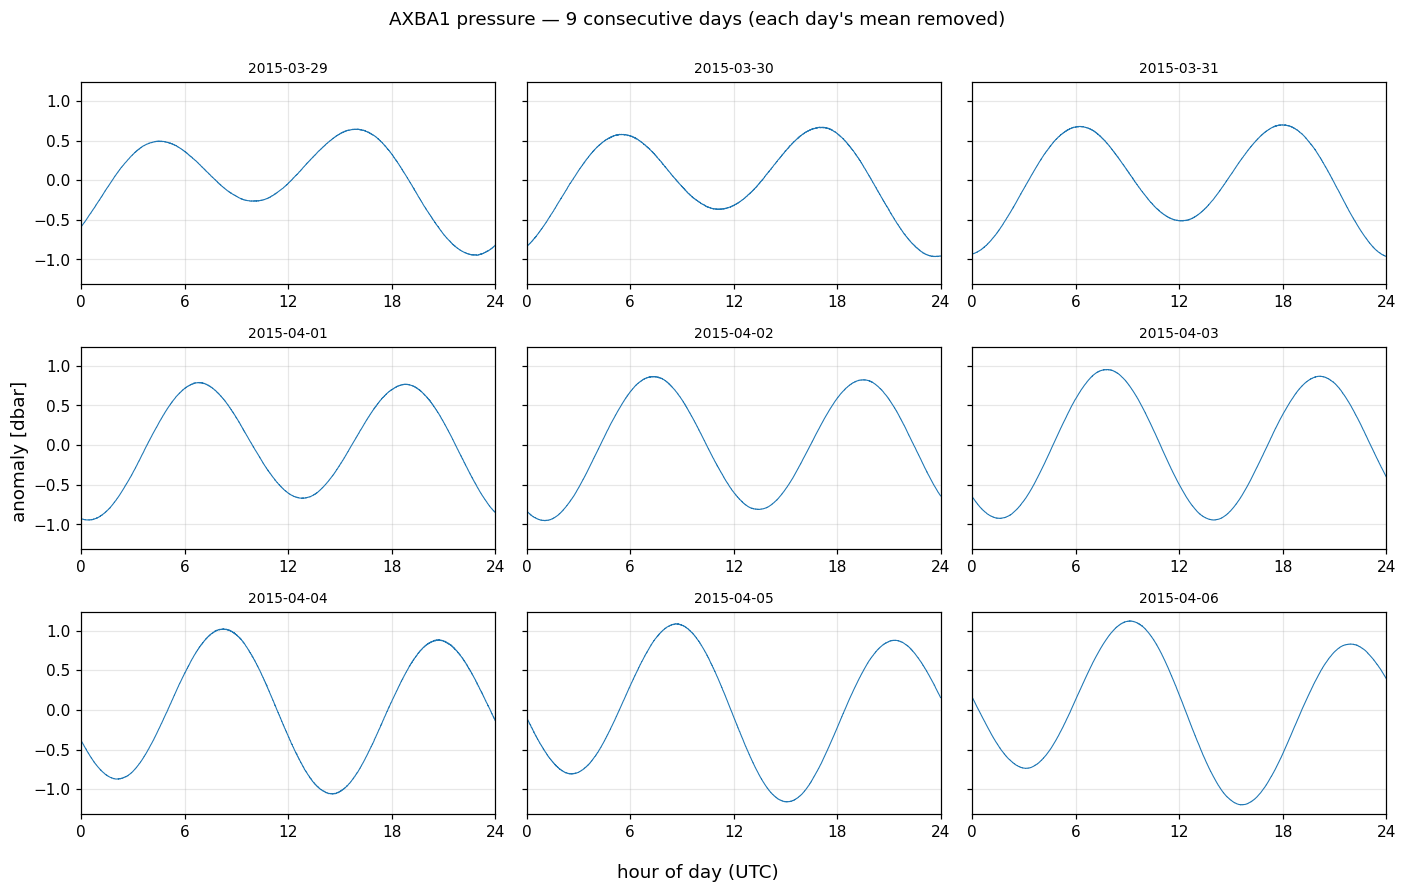

In [3]:
N = 9
fig, axes = plt.subplots(3, 3, figsize=(13, 8), sharey=True)
for i, ax in enumerate(axes.flat):
    d = start + pd.Timedelta(days=i)
    s = ol.load_series(STATION, VAR, d, d)
    if len(s):
        hrs = (s.index - d) / pd.Timedelta(hours=1)        # convert timestamps -> hours into the day
        ax.plot(hrs, s.values - s.mean(), lw=0.7)          # minus daily mean
    ax.set_title(d.strftime("%Y-%m-%d"), fontsize=9)
    ax.set_xlim(0, 24); ax.set_xticks([0, 6, 12, 18, 24])
fig.suptitle(f"{STATION} {VAR} — {N} consecutive days (each day's mean removed)", y=1.0)
fig.supxlabel("hour of day (UTC)"); fig.supylabel(f"anomaly [{ol.VARIABLES[VAR]['units']}]")
plt.tight_layout(); ol.savefig(fig, f"03_{STATION}_day_grid.png"); plt.show()

> 👀 **What you're seeing**
>
> Read left-to-right, top-to-bottom (consecutive days). Watch the twin daily humps **shift slightly rightward** each day (the 50-min lunar drift) and the **overall amplitude grow or shrink** across the 9 days (heading into spring or neap tides).

## View 2 — all days overlaid on one 24-hour axis

Now stack 30 days on the *same* 0–24 h axis, colouring each day by how far into
the month it is. This 'spaghetti plot' shows the spread of tidal behaviour.

saved /Users/quakehunter/Documents/data_exploration/figures/03_AXBA1_daily_overlay.png


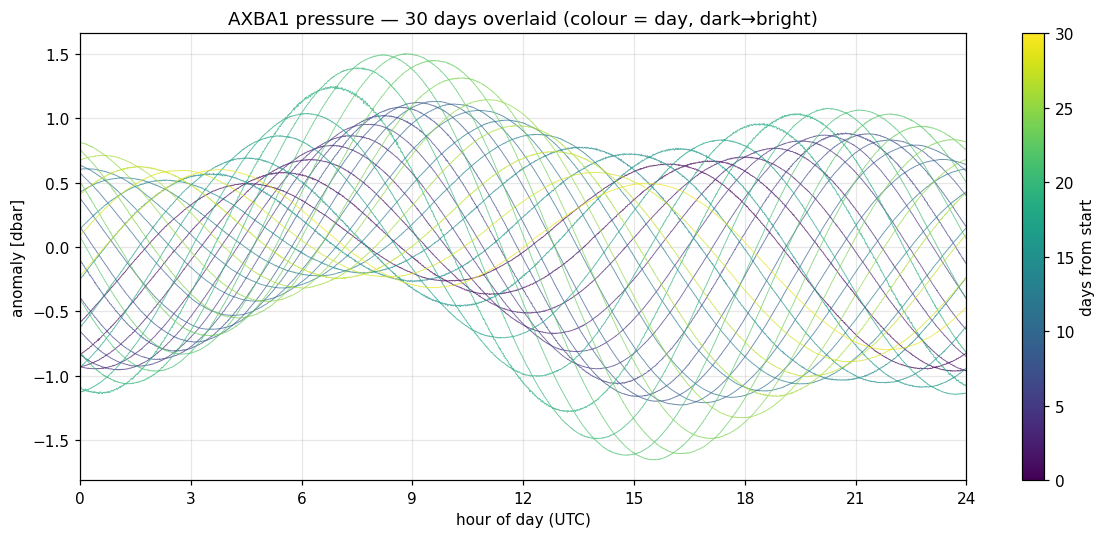

In [4]:
NDAYS = 30
fig, ax = plt.subplots(figsize=(11, 5))
cmap = plt.cm.viridis
for i in range(NDAYS):
    d = start + pd.Timedelta(days=i)
    s = ol.load_series(STATION, VAR, d, d)
    if not len(s):
        continue
    hrs = (s.index - d) / pd.Timedelta(hours=1)
    ax.plot(hrs, s.values - s.mean(), lw=0.6, color=cmap(i / NDAYS), alpha=0.7)
ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 3))
ax.set_xlabel("hour of day (UTC)"); ax.set_ylabel(f"anomaly [{ol.VARIABLES[VAR]['units']}]")
ax.set_title(f"{STATION} {VAR} — {NDAYS} days overlaid (colour = day, dark→bright)")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, NDAYS))
fig.colorbar(sm, ax=ax, label="days from start")
plt.tight_layout(); ol.savefig(fig, f"03_{STATION}_daily_overlay.png"); plt.show()

> 👀 **What you're seeing**
>
> The way the colours *fan out* shows the tide's phase marching around the clock over the month (the 50-min/day drift, accumulated). The envelope's width shows how much the tidal range varies between spring and neap.

## View 3 — hour-of-day × date heatmap (the clearest view)

Put **hour of day** on the vertical axis, **date** on the horizontal, and colour
each cell by the pressure anomaly. Spring–neap and the phase drift appear as
clean patterns.

saved /Users/quakehunter/Documents/data_exploration/figures/03_AXBA1_hour_date_heatmap.png


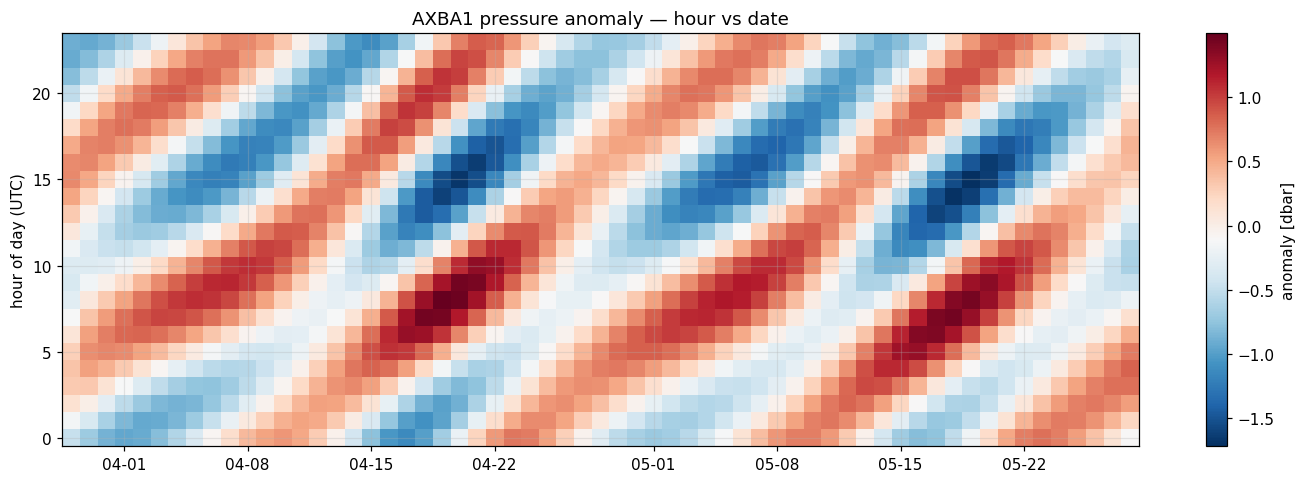

In [5]:
NDAYS = 60
s = ol.load_decimated(STATION, VAR, start, start + pd.Timedelta(days=NDAYS), rule="1h")
anom = s - s.rolling(24, center=True, min_periods=1).mean()   # remove slow daily drift

grid = anom.to_frame("v")
grid["date"] = grid.index.normalize()      # the calendar day
grid["hour"] = grid.index.hour             # 0..23
mat = grid.pivot_table(index="hour", columns="date", values="v")   # hour × date table

fig, ax = plt.subplots(figsize=(13, 4.5))
im = ax.pcolormesh(mat.columns, mat.index, mat.values, shading="auto", cmap="RdBu_r")
ax.set_ylabel("hour of day (UTC)"); ax.set_title(f"{STATION} {VAR} anomaly — hour vs date")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
fig.colorbar(im, ax=ax, label=f"anomaly [{ol.VARIABLES[VAR]['units']}]")
plt.tight_layout(); ol.savefig(fig, f"03_{STATION}_hour_date_heatmap.png"); plt.show()

> 👀 **What you're seeing**
>
> Red = above average, blue = below. The **diagonal stripes** are the tide's high/low times sliding ~50 min later each day. The **fading and strengthening of the colours** every ~2 weeks is the spring–neap cycle. This single picture encodes everything the first two views hinted at.

> ✏️ **Try it yourself**
>
> 1. Find a neap (weak) period in the heatmap, then plot that exact day with View 1's code.
> 2. Switch `VAR='temperature'` in View 3. Is the tidal striping visible in temperature too?
> 3. Increase `NDAYS` to 120 in the heatmap — count how many spring–neap cycles you see.

> ✅ **Recap**
>
> Three ways to view daily structure — a day grid, a 24-hour overlay, and an hour×date heatmap — and you can now spot the spring–neap cycle and the ~50-min/day lunar drift by eye.
>
> ➡️ **Next:** `04_detide_harmonic_analysis.ipynb` — predict the tide mathematically and subtract it.